In [1]:
import pandas as pd
df=pd.read_csv("/content/bank_transactions.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [3]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


In [4]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [11]:
# The 'CustomerDOB' column was previously dropped. We will work with the existing 'Age' column.
df.loc[df['Age'] < 0, 'Age'] = df.loc[df['Age'] < 0, 'Age'] + 100

# Recalculate median age after initial correction for more accurate imputation
median_age = df['Age'].median()

# Impute any remaining NaN values in 'Age' (from original NaT in CustomerDOB) with the (recalculated) median age
df['Age'] = df['Age'].fillna(median_age)

# Replace ages less than 18 with the median age, assuming banking customers are typically adults
df.loc[df['Age'] < 18, 'Age'] = median_age

# Ensure TransactionDate is datetime type (if it wasn't already from previous successful run)
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d/%m/%y')

# Impute CustGender with the mode (using re-assignment instead of inplace=True)
mode_gender = df['CustGender'].mode()[0]
df['CustGender'] = df['CustGender'].fillna(mode_gender)

# Impute CustLocation with the mode (using re-assignment instead of inplace=True)
mode_location = df['CustLocation'].mode()[0]
df['CustLocation'] = df['CustLocation'].fillna(mode_location)

# Impute CustAccountBalance with the median (using re-assignment instead of inplace=True)
median_balance = df['CustAccountBalance'].median()
df['CustAccountBalance'] = df['CustAccountBalance'].fillna(median_balance)

print("Missing values after age correction and imputation:")
print(df.isnull().sum())
df.info()


Missing values after age correction and imputation:
TransactionID              0
CustomerID                 0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
Age                        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1048567 non-null  object        
 1   CustomerID               1048567 non-null  object        
 2   CustGender               1048567 non-null  object        
 3   CustLocation             1048567 non-null  object        
 4   CustAccountBalance       1048567 non-null  float64       
 5   TransactionDate          1048567 non-null  datetime64[ns]
 6   TransactionTime          1048567 non-null  int64     

In [10]:
df.describe()

,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
count,1.048567e+06,1048567,1.048567e+06,1.048567e+06,1.048567e+06
mean,1.151807e+05,2016-08-25 04:33:33.797497600,1.570875e+05,1.574335e+03,3.566806e+01
min,0.000000e+00,2016-08-01 00:00:00,0.000000e+00,0.000000e+00,-4.200000e+01
25%,4.740200e+03,2016-08-12 00:00:00,1.240300e+05,1.610000e+02,3.500000e+01
50%,1.679218e+04,2016-08-25 00:00:00,1.642260e+05,4.590300e+02,3.800000e+01
75%,5.747288e+04,2016-09-06 00:00:00,2.000100e+05,1.200000e+03,4.200000e+01
max,1.150355e+08,2016-10-21 00:00:00,2.359590e+05,1.560035e+06,5.700000e+01
std,8.455416e+05,NaN,5.126185e+04,6.574743e+03,1.728756e+01


In [7]:
df.describe()

,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
count,1.048567e+06,1048567,1.048567e+06,1.048567e+06,1.048567e+06
mean,1.151807e+05,2016-08-25 04:33:33.797497600,1.570875e+05,1.574335e+03,3.566806e+01
min,0.000000e+00,2016-08-01 00:00:00,0.000000e+00,0.000000e+00,-4.200000e+01
25%,4.740200e+03,2016-08-12 00:00:00,1.240300e+05,1.610000e+02,3.500000e+01
50%,1.679218e+04,2016-08-25 00:00:00,1.642260e+05,4.590300e+02,3.800000e+01
75%,5.747288e+04,2016-09-06 00:00:00,2.000100e+05,1.200000e+03,4.200000e+01
max,1.150355e+08,2016-10-21 00:00:00,2.359590e+05,1.560035e+06,5.700000e+01
std,8.455416e+05,NaN,5.126185e+04,6.574743e+03,1.728756e+01


In [8]:
print(f"Number of customers with negative age: {(df['Age'] < 0).sum()}")
print(f"Customers with age less than 18: {(df['Age'] < 18).sum()}")
# Let's inspect some of these rows to understand the cause
df[df['Age'] < 0].head()

Number of customers with negative age: 54372
Customers with age less than 18: 54556


,TransactionID,CustomerID,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
1,T2,C2142763,M,JHAJJAR,2270.69,2016-08-02,141858,27999.00,-31.0
15,T16,C8334633,F,NEW DELHI,1283.12,2016-08-01,125725,250.00,-42.0
30,T31,C7648712,F,NEW DELHI,298461.05,2016-08-03,160642,500.00,-41.0
51,T52,C6637047,M,PUNE,9956.49,2016-08-05,133141,145.00,-40.0
79,T80,C6612422,M,DELHI,257966.29,2016-08-01,204252,195.64,-41.0


In [12]:
# Re-apply correction for negative ages: if Age = -34, it should be 2026 - (2060 - 100) = 66.
# So, for negative ages, add 100 to correct.
df.loc[df['Age'] < 0, 'Age'] = df.loc[df['Age'] < 0, 'Age'] + 100

# Recalculate median age after this correction for robust imputation
median_age_corrected = df['Age'].median()

# Replace ages less than 18 with the (newly calculated) median age
df.loc[df['Age'] < 18, 'Age'] = median_age_corrected

print("Age column after re-correction:")
display(df[['Age']].describe())

print(f"Number of customers with negative age after re-correction: {(df['Age'] < 0).sum()}")
print(f"Customers with age less than 18 after re-correction: {(df['Age'] < 18).sum()}")

Age column after re-correction:


,Age
count,1.048567e+06
mean,4.085820e+01
std,8.523137e+00
min,1.800000e+01
25%,3.500000e+01
50%,3.800000e+01
75%,4.400000e+01
max,9.900000e+01


Number of customers with negative age after re-correction: 0
Customers with age less than 18 after re-correction: 0


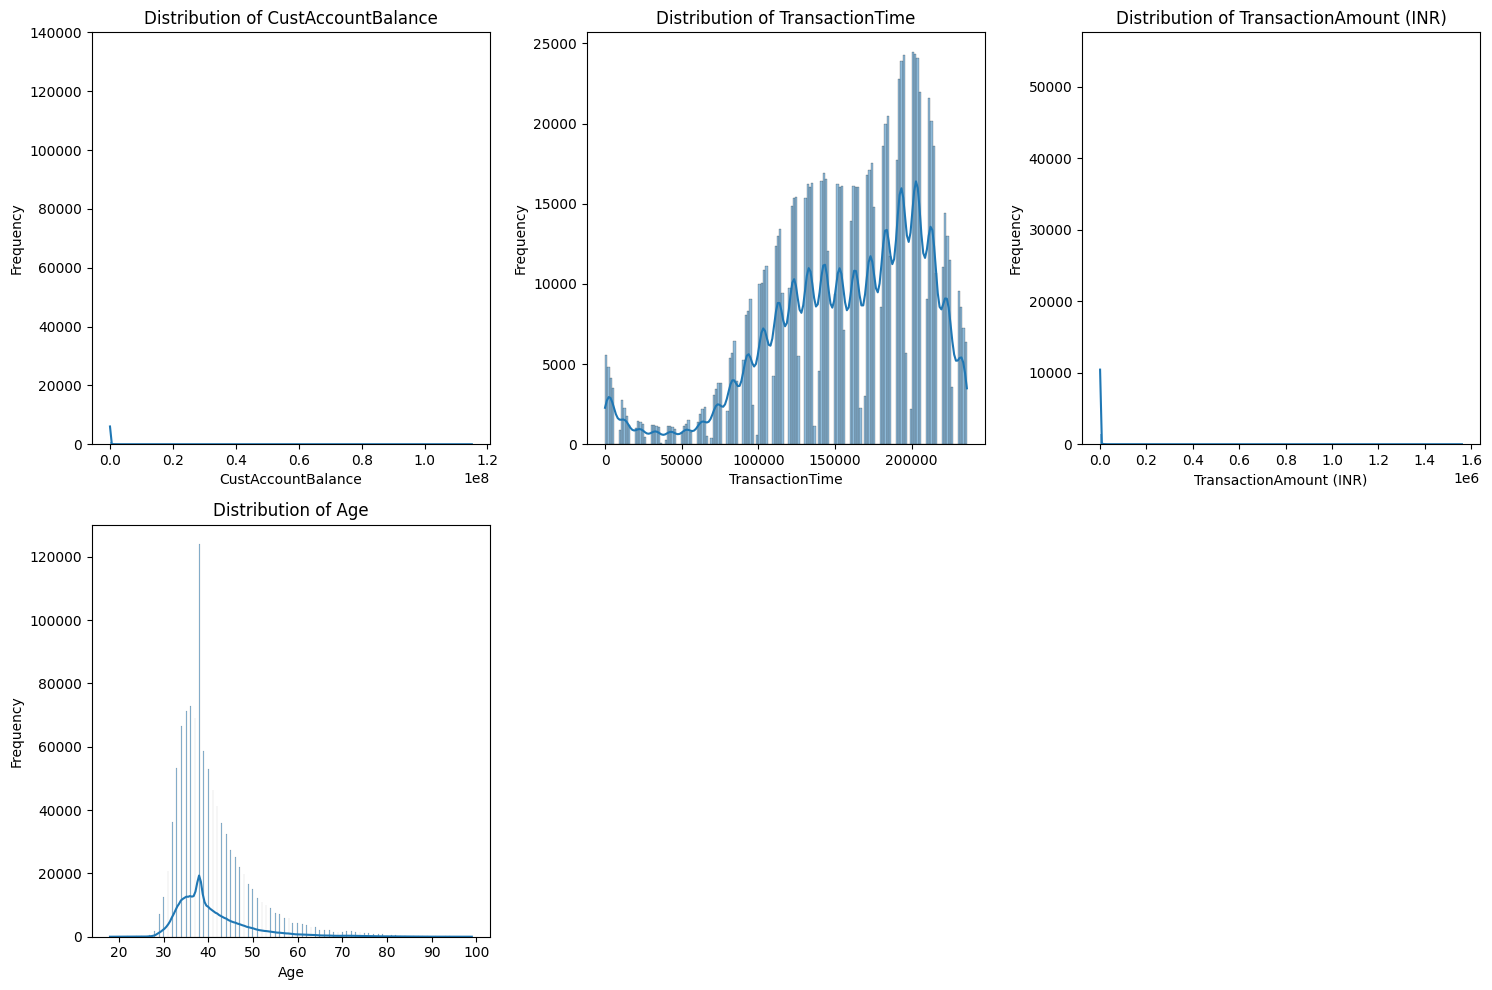

Descriptive statistics for numerical features after cleaning:


,CustAccountBalance,TransactionTime,TransactionAmount (INR),Age
count,1.048567e+06,1.048567e+06,1.048567e+06,1.048567e+06
mean,1.151807e+05,1.570875e+05,1.574335e+03,4.085820e+01
std,8.455416e+05,5.126185e+04,6.574743e+03,8.523137e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01
25%,4.740200e+03,1.240300e+05,1.610000e+02,3.500000e+01
50%,1.679218e+04,1.642260e+05,4.590300e+02,3.800000e+01
75%,5.747288e+04,2.000100e+05,1.200000e+03,4.400000e+01
max,1.150355e+08,2.359590e+05,1.560035e+06,9.900000e+01


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for EDA
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot distributions of numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Descriptive statistics for numerical features after cleaning:")
display(df[numerical_cols].describe())

Descriptive statistics for categorical features after cleaning:

--- TransactionID ---
TransactionID
T1048567    1
T1          1
T2          1
T3          1
T4          1
           ..
T12         1
T11         1
T10         1
T9          1
T8          1
Name: count, Length: 1048567, dtype: int64

--- CustomerID ---
CustomerID
C3226689    6
C5418253    6
C1113684    6
C6624352    6
C4327447    6
           ..
C8736461    1
C6937679    1
C3422316    1
C3732016    1
C8999019    1
Name: count, Length: 884265, dtype: int64

--- CustGender ---
CustGender
M    766630
F    281936
T         1
Name: count, dtype: int64

--- CustLocation ---
CustLocation
MUMBAI                           103746
NEW DELHI                         84928
BANGALORE                         81555
GURGAON                           73818
DELHI                             71019
                                  ...  
SAHIBGANJ                             1
24 PARGANAS SOUTH 24 PARGANAS         1
PREMISES KALYANI NAGAR PUNE

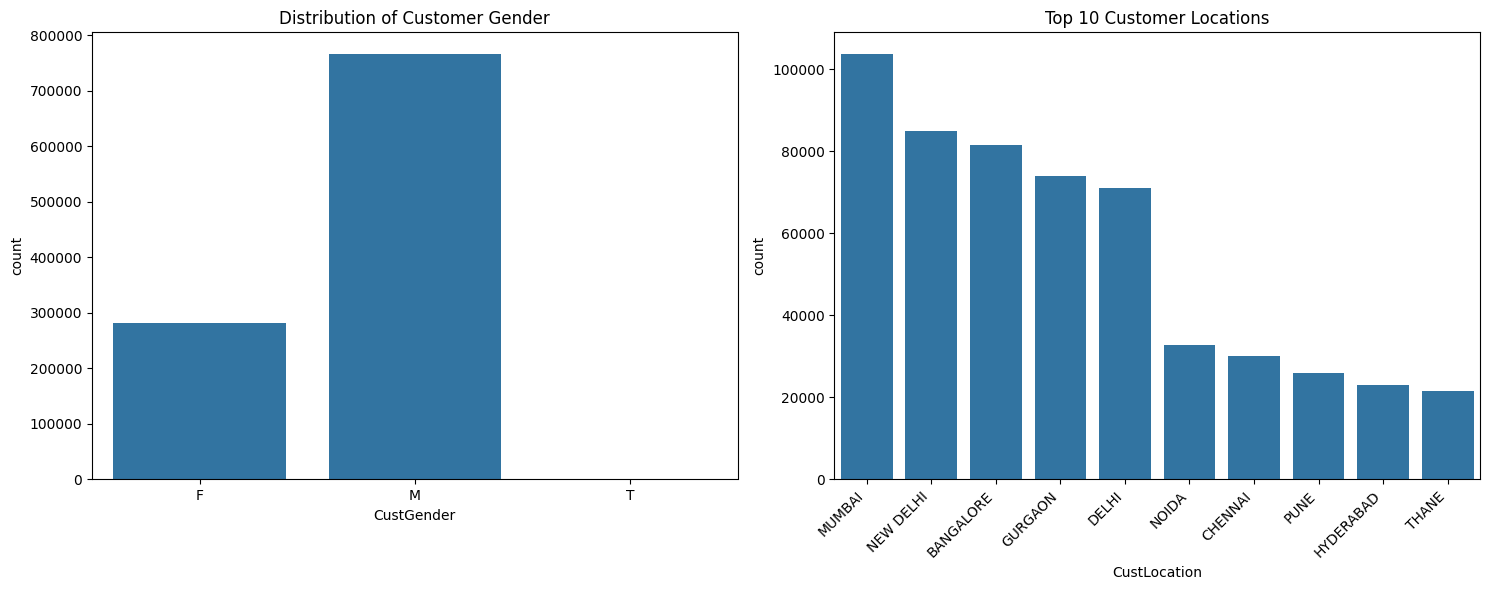

In [14]:
# Identify categorical columns for EDA
categorical_cols = df.select_dtypes(include=['object']).columns

print("Descriptive statistics for categorical features after cleaning:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


# Plot distributions of categorical features
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='CustGender')
plt.title('Distribution of Customer Gender')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='CustLocation', order=df['CustLocation'].value_counts().iloc[:10].index) # Top 10 locations
plt.title('Top 10 Customer Locations')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

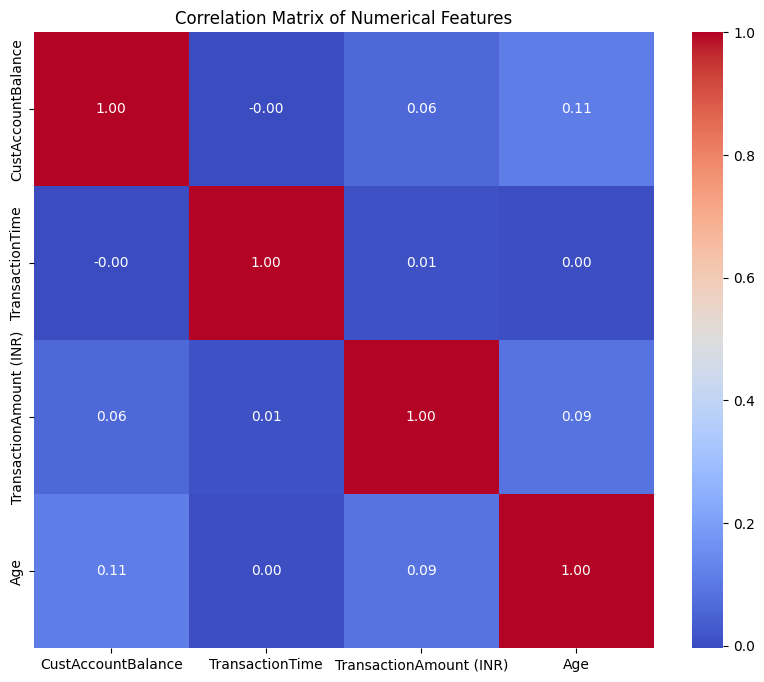

In [15]:
# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

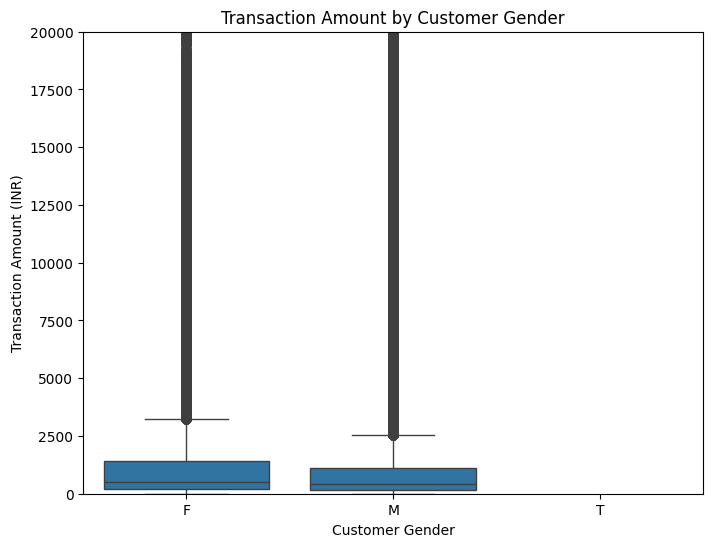

Descriptive statistics of Transaction Amount by CustGender:


,count,mean,std,min,25%,50%,75%,max
CustGender,,,,,,,,
F,281936.0,1655.733753,6342.270657,0.0,200.0,520.0,1419.0,1380002.88
M,766630.0,1544.359443,6657.860076,0.0,150.0,420.0,1105.0,1560034.99
T,1.0,32500.000000,NaN,32500.0,32500.0,32500.0,32500.0,32500.00


In [16]:
# Analyze the relationship between CustGender and TransactionAmount (INR)
plt.figure(figsize=(8, 6))
sns.boxplot(x='CustGender', y='TransactionAmount (INR)', data=df)
plt.title('Transaction Amount by Customer Gender')
plt.xlabel('Customer Gender')
plt.ylabel('Transaction Amount (INR)')
plt.ylim(0, df['TransactionAmount (INR)'].quantile(0.99)) # Limit y-axis to focus on the majority of data
plt.show()

print("Descriptive statistics of Transaction Amount by CustGender:")
display(df.groupby('CustGender')['TransactionAmount (INR)'].describe())

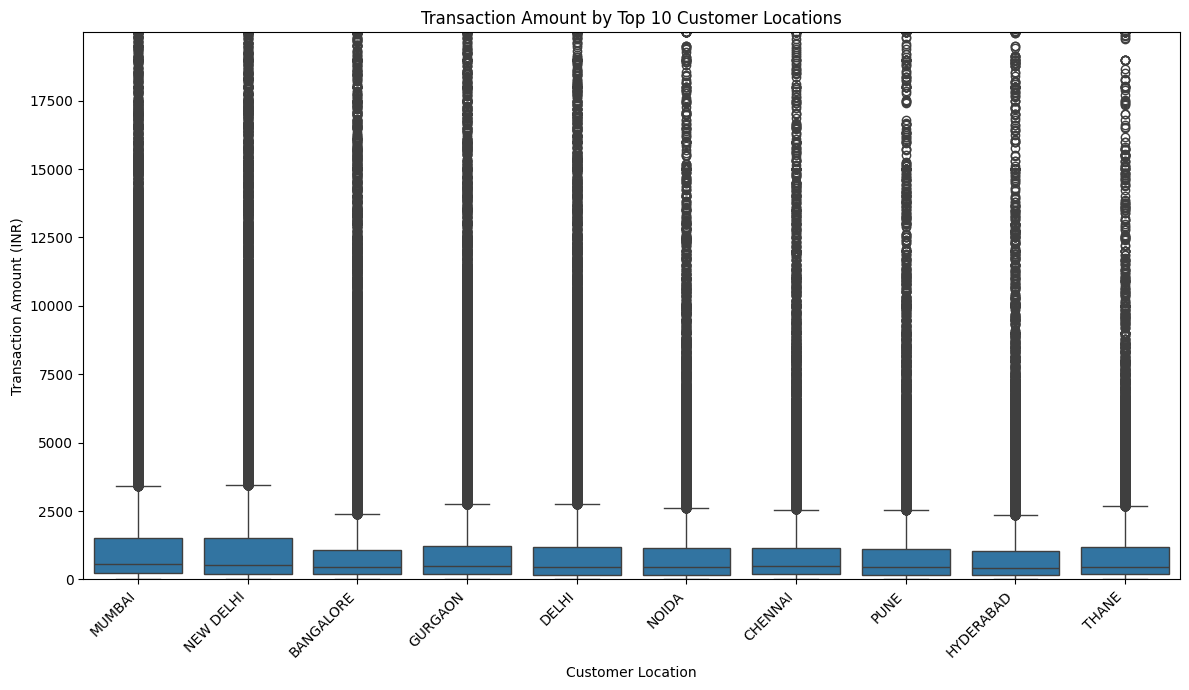

Descriptive statistics of Transaction Amount by Top 10 CustLocation:


,count,mean,std,min,25%,50%,75%,max
CustLocation,,,,,,,,
MUMBAI,103746.0,1734.318829,6784.952700,0.0,220.0000,575.00,1500.00,724122.00
NEW DELHI,84928.0,1892.259948,8213.274100,0.0,200.0000,518.00,1500.00,991132.22
BANGALORE,81555.0,1452.085624,5712.047278,0.0,200.0000,449.00,1080.00,500000.00
GURGAON,73818.0,1518.527926,7931.232804,0.0,192.0000,497.00,1214.00,1560034.99
DELHI,71019.0,1495.725647,5671.710235,0.0,163.7200,472.73,1200.00,569500.27
NOIDA,32784.0,1356.254060,6020.973792,0.0,156.6575,450.00,1134.00,600008.32
CHENNAI,30009.0,1487.481137,5369.118321,0.0,200.0000,486.00,1143.00,265414.00
PUNE,25851.0,1531.482293,10370.150895,0.0,180.0000,442.00,1125.86,1380002.88
HYDERABAD,23049.0,1569.586291,6881.027395,0.0,168.6700,412.00,1040.00,450000.00


In [17]:
# Analyze the relationship between CustLocation and TransactionAmount (INR)
# Let's consider the top 10 locations to keep the plot readable
top_10_locations = df['CustLocation'].value_counts().nlargest(10).index
filtered_df = df[df['CustLocation'].isin(top_10_locations)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='CustLocation', y='TransactionAmount (INR)', data=filtered_df, order=top_10_locations)
plt.title('Transaction Amount by Top 10 Customer Locations')
plt.xlabel('Customer Location')
plt.ylabel('Transaction Amount (INR)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, filtered_df['TransactionAmount (INR)'].quantile(0.99)) # Limit y-axis for better visualization
plt.tight_layout()
plt.show()

print("Descriptive statistics of Transaction Amount by Top 10 CustLocation:")
display(filtered_df.groupby('CustLocation')['TransactionAmount (INR)'].describe().loc[top_10_locations])

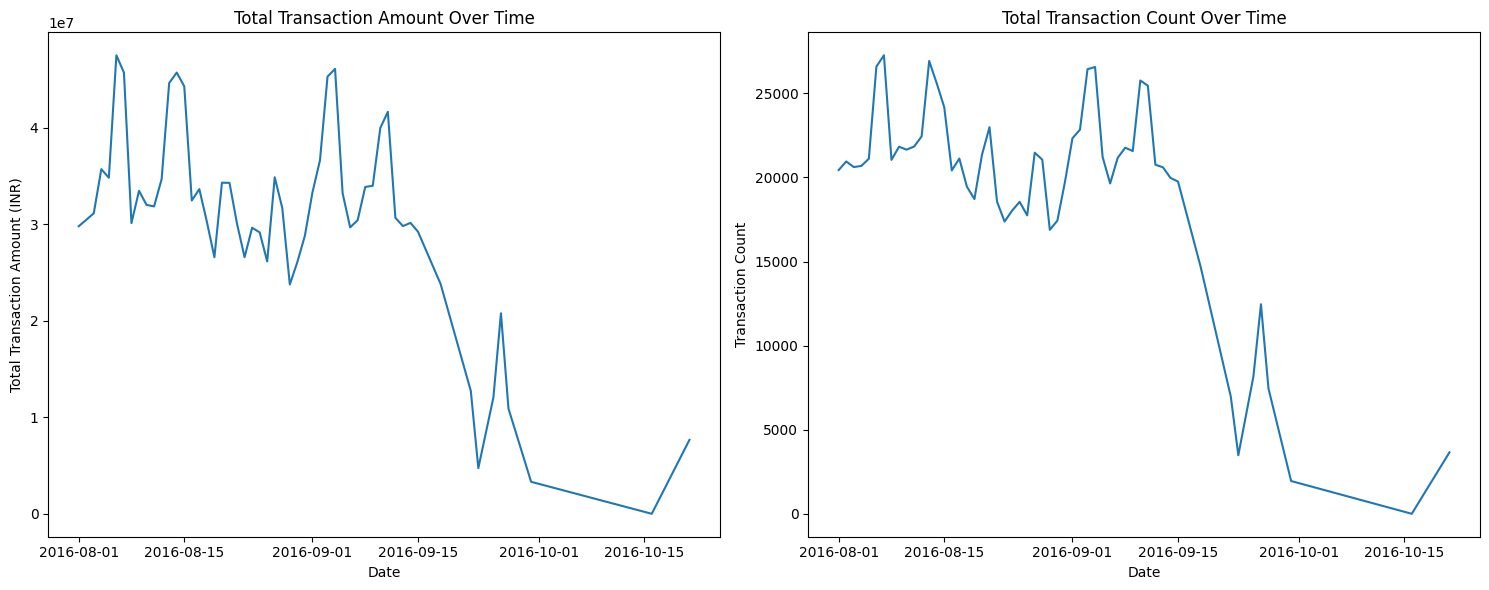

In [18]:
# Analyze temporal trends: daily transaction amount and count

daily_transactions = df.groupby('TransactionDate').agg(
    total_amount=('TransactionAmount (INR)', 'sum'),
    transaction_count=('TransactionID', 'count')
).reset_index()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=daily_transactions, x='TransactionDate', y='total_amount')
plt.title('Total Transaction Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Transaction Amount (INR)')

plt.subplot(1, 2, 2)
sns.lineplot(data=daily_transactions, x='TransactionDate', y='transaction_count')
plt.title('Total Transaction Count Over Time')
plt.xlabel('Date')
plt.ylabel('Transaction Count')

plt.tight_layout()
plt.show()

In [19]:
df['TransactionHour'] = df['TransactionTime'] // 10000
df['TransactionMinute'] = (df['TransactionTime'] % 10000) // 100
df['TransactionSecond'] = df['TransactionTime'] % 100

df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionDay'] = df['TransactionDate'].dt.day

# Aggregate features per customer
customer_features = df.groupby('CustomerID').agg(
    NumTransactions=('TransactionID', 'count'),
    TotalTransactionAmount=('TransactionAmount (INR)', 'sum'),
    AverageTransactionAmount=('TransactionAmount (INR)', 'mean'),
    MaxTransactionAmount=('TransactionAmount (INR)', 'max'),
    MinTransactionAmount=('TransactionAmount (INR)', 'min'),
    CustomerAge=('Age', 'first'), # Assuming age doesn't change significantly over the short period
    CustomerGender=('CustGender', lambda x: x.mode()[0]), # Most frequent gender
    CustomerBalance=('CustAccountBalance', 'last') # Latest account balance
).reset_index()

print("New customer-level features created:")
display(customer_features.head())
print("Descriptive statistics for new numerical customer features:")
display(customer_features.describe())

New customer-level features created:


,CustomerID,NumTransactions,TotalTransactionAmount,AverageTransactionAmount,MaxTransactionAmount,MinTransactionAmount,CustomerAge,CustomerGender,CustomerBalance
0,C1010011,2,5106.0,2553.0,4750.0,356.0,34.0,F,120180.54
1,C1010012,1,1499.0,1499.0,1499.0,1499.0,32.0,M,24204.49
2,C1010014,2,1455.0,727.5,1205.0,250.0,34.0,F,161848.76
3,C1010018,1,30.0,30.0,30.0,30.0,36.0,F,496.18
4,C1010024,1,5000.0,5000.0,5000.0,5000.0,61.0,M,87058.65


Descriptive statistics for new numerical customer features:


,NumTransactions,TotalTransactionAmount,AverageTransactionAmount,MaxTransactionAmount,MinTransactionAmount,CustomerAge,CustomerBalance
count,884265.000000,8.842650e+05,8.842650e+05,8.842650e+05,8.842650e+05,884265.000000,8.842650e+05
mean,1.185806,1.866856e+03,1.574781e+03,1.788667e+03,1.379961e+03,40.858955,1.151931e+05
std,0.450683,7.207210e+03,6.443050e+03,7.125466e+03,6.250537e+03,8.519907,8.559064e+05
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,18.000000,0.000000e+00
25%,1.000000,2.000000e+02,1.920000e+02,2.000000e+02,1.310000e+02,35.000000,4.755810e+03
50%,1.000000,5.368000e+02,5.000000e+02,5.000000e+02,3.760000e+02,38.000000,1.679218e+04
75%,1.000000,1.500000e+03,1.248000e+03,1.420000e+03,1.000000e+03,44.000000,5.749403e+04
max,6.000000,1.560035e+06,1.560035e+06,1.560035e+06,1.560035e+06,99.000000,1.150355e+08


### Feature Scaling

In [20]:
# Identify numerical features for scaling
# Exclude 'CustomerID' and categorical features like 'CustomerGender'

# Make a copy to avoid modifying the original customer_features dataframe directly
customer_features_scaled = customer_features.copy()

numerical_cols_for_scaling = [
    'NumTransactions',
    'TotalTransactionAmount',
    'AverageTransactionAmount',
    'MaxTransactionAmount',
    'MinTransactionAmount',
    'CustomerAge',
    'CustomerBalance'
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
customer_features_scaled[numerical_cols_for_scaling] = scaler.fit_transform(customer_features_scaled[numerical_cols_for_scaling])

print("Scaled customer features (first 5 rows):")
display(customer_features_scaled.head())

print("Descriptive statistics of scaled numerical customer features:")
display(customer_features_scaled[numerical_cols_for_scaling].describe())

Scaled customer features (first 5 rows):


,CustomerID,NumTransactions,TotalTransactionAmount,AverageTransactionAmount,MaxTransactionAmount,MinTransactionAmount,CustomerAge,CustomerGender,CustomerBalance
0,C1010011,1.806577,0.449431,0.151826,0.415599,-0.163820,-0.805051,F,0.005827
1,C1010012,-0.412277,-0.051040,-0.011762,-0.040652,0.019045,-1.039795,M,-0.106307
2,C1010014,1.806577,-0.057145,-0.131503,-0.081913,-0.180778,-0.805051,F,0.054510
3,C1010018,-0.412277,-0.254864,-0.239759,-0.246814,-0.215975,-0.570306,F,-0.134006
4,C1010024,-0.412277,0.434724,0.531615,0.450684,0.579157,2.364000,M,-0.032871


Descriptive statistics of scaled numerical customer features:


,NumTransactions,TotalTransactionAmount,AverageTransactionAmount,MaxTransactionAmount,MinTransactionAmount,CustomerAge,CustomerBalance
count,8.842650e+05,8.842650e+05,8.842650e+05,8.842650e+05,8.842650e+05,8.842650e+05,8.842650e+05
mean,3.288088e-17,-2.802749e-17,-1.485907e-16,-2.763376e-17,1.788681e-17,-5.288904e-17,-5.183238e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-4.122771e-01,-2.590264e-01,-2.444156e-01,-2.510247e-01,-2.207749e-01,-2.683007e+00,-1.345861e-01
25%,-4.122771e-01,-2.312764e-01,-2.146160e-01,-2.229563e-01,-1.998167e-01,-6.876787e-01,-1.290297e-01
50%,-4.122771e-01,-1.845454e-01,-1.668126e-01,-1.808538e-01,-1.606201e-01,-3.355620e-01,-1.149669e-01
75%,-4.122771e-01,-5.090133e-02,-5.071840e-02,-5.173938e-02,-6.078860e-02,3.686715e-01,-6.741282e-02
max,1.068199e+01,2.161959e+02,2.418825e+02,2.186871e+02,2.493635e+02,6.824145e+00,1.342674e+02


### Determining Optimal Number of Clusters - Elbow Method

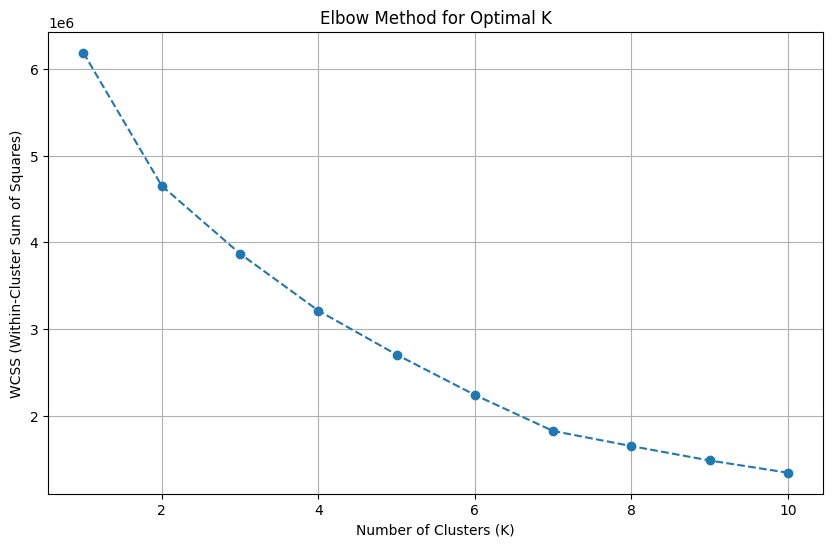

In [21]:
# Prepare data for clustering: select only the scaled numerical features
X = customer_features_scaled[numerical_cols_for_scaling]

wcss = []
# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

### Applying K-Means Clustering

Based on the Elbow Method, which showed a significant bend around K=3 or K=4, we will proceed with **K=4** for our K-Means clustering. While the Silhouette Score provides a quantitative measure, its computational cost on large datasets can be prohibitive. The Elbow Method often provides a sufficient visual guide.

We will now apply the K-Means algorithm to our scaled customer features and assign a cluster label to each customer.

In [24]:
# Choose the optimal number of clusters based on the Elbow Method (e.g., K=4)
optimal_k = 4

# Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Fit K-Means to the scaled data
kmeans.fit(X)

# Add the cluster labels back to the original customer features DataFrame
customer_features['Cluster'] = kmeans.labels_

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("Cluster distribution:")
display(customer_features['Cluster'].value_counts().sort_index())

K-Means clustering applied with 4 clusters.
Cluster distribution:


,count
Cluster,
0,736919
1,29
2,4420
3,142897


### Profiling Customer Segments

Now that customers have been assigned to clusters, the next step is to understand the characteristics of each segment. We will do this by analyzing the mean values of the *original* (unscaled) features for each cluster. This will provide insights into what defines each customer group and help us to interpret their behavior.

In [26]:
# Identify numerical columns for profiling, excluding 'CustomerID' and 'CustomerGender'
numerical_profile_cols = [
    'NumTransactions',
    'TotalTransactionAmount',
    'AverageTransactionAmount',
    'MaxTransactionAmount',
    'MinTransactionAmount',
    'CustomerAge',
    'CustomerBalance'
]

# Calculate the mean of numerical features for each cluster
cluster_profiles = customer_features.groupby('Cluster')[numerical_profile_cols].mean()

# Display the cluster profiles
print("Customer Segment Profiles (Mean values of numerical features):")
display(cluster_profiles)

# For better interpretation, let's also look at the categorical features if any
# In our customer_features, 'CustomerGender' is categorical.

print("\nCustomer Gender Distribution per Cluster:")
display(customer_features.groupby('Cluster')['CustomerGender'].value_counts(normalize=True).unstack(fill_value=0))

Customer Segment Profiles (Mean values of numerical features):


,NumTransactions,TotalTransactionAmount,AverageTransactionAmount,MaxTransactionAmount,MinTransactionAmount,CustomerAge,CustomerBalance
Cluster,,,,,,,
0,1.000000,1251.574647,1251.574647,1251.574647,1251.574647,40.834911,112045.855602
1,1.034483,580241.258276,567750.361724,580229.189310,555271.534138,48.965517,405461.488276
2,1.193439,66639.981686,58647.036230,66108.137213,52069.497145,45.333710,566569.198568
3,2.143803,2918.961760,1361.329700,2451.569175,361.744475,40.842894,117402.578236



Customer Gender Distribution per Cluster:


CustomerGender,F,M,T
Cluster,,,
0,0.268924,0.731076,0.000000
1,0.310345,0.689655,0.000000
2,0.274434,0.725339,0.000226
3,0.429365,0.570635,0.000000


### Business Recommendations for Personalized Banking System

Based on the identified customer segments, we can develop tailored strategies to enhance customer experience, retention, and profitability. Here are the recommendations for each cluster:

**Cluster 0: "Everyday Users" (Largest Segment)**

*   **Characteristics**: This is the largest segment, representing the bulk of the customer base with average transaction behavior and account balances. They make a single transaction during the observed period.
*   **Recommendations**:
    *   **Engagement**: Focus on increasing engagement and transaction frequency. Introduce loyalty programs, cashback offers, or discounts on recurring bills.
    *   **Product Upselling**: Offer personalized recommendations for basic banking products like savings accounts with slightly higher interest rates, small personal loans, or secure credit cards (with low limits).
    *   **Digital Adoption**: Encourage the use of mobile banking apps and online services through tutorials and incentives to reduce operational costs.
    *   **Financial Literacy**: Provide educational content on basic financial planning, budgeting tools, and savings tips to help them grow their wealth.

**Cluster 1: "High-Net-Worth Individuals (HNWIs)" (Smallest, but Highest Value Segment)**

*   **Characteristics**: A very small but extremely valuable segment. These customers have significantly high transaction amounts, high average transaction amounts, and very high account balances. They are slightly older.
*   **Recommendations**:
    *   **Dedicated Relationship Management**: Assign personal bankers or wealth managers to provide bespoke financial advice and services.
    *   **Exclusive Products**: Offer exclusive high-yield investment opportunities, private banking services, wealth management, and tailored insurance products.
    *   **Premium Benefits**: Provide premium perks such as preferential interest rates, fee waivers, exclusive lounge access, and concierge services.
    *   **Security & Privacy**: Emphasize advanced security features and personalized privacy controls due to their high asset value.

**Cluster 2: "Affluent Customers" (Mid-Size High-Value Segment)**

*   **Characteristics**: These customers exhibit high transaction values and account balances, though not as extreme as HNWIs. They have a slightly higher number of transactions than the Everyday Users.
*   **Recommendations**:
    *   **Tiered Premium Services**: Offer premium banking packages that include benefits like priority service, higher transaction limits, travel rewards, and investment advisory services.
    *   **Targeted Investment Products**: Recommend a range of investment products such as mutual funds, fixed deposits, and retirement planning solutions.
    *   **Financial Advisory**: Provide access to financial advisors for portfolio management and tax planning.
    *   **Customized Credit Solutions**: Offer higher-limit credit cards with attractive rewards and favorable loan terms for mortgages or business expansion.

**Cluster 3: "Active Engaged Transactors" (Second Largest Segment)**

*   **Characteristics**: This segment shows a high frequency of transactions with moderate individual amounts, suggesting regular and active banking usage. They have a more balanced gender distribution.
*   **Recommendations**:
    *   **Rewards for Activity**: Implement a robust rewards program that grants points or benefits based on transaction volume and frequency.
    *   **Convenience & Efficiency**: Focus on streamlining digital transaction processes, ensuring fast and reliable online and mobile banking experiences.
    *   **Budgeting & Tracking Tools**: Offer advanced budgeting tools, expense categorization, and financial health dashboards within the banking app to help them manage frequent transactions.
    *   **Cross-selling**: Promote products that complement active transactional behavior, such as easy-to-use credit cards for daily expenses, micro-investment options, or small recurring deposit schemes.